In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"D:\Projects\Data\Supply_Chain_dataset.csv")

df['shipping_date_(DateOrders)'] = pd.to_datetime(df['shipping_date_(DateOrders)'])
df['order_date_(DateOrders)'] = pd.to_datetime(df['order_date_(DateOrders)'])
df = df.drop(columns="Order_Zipcode")
df = df.drop(columns="Product_Description")
df= df.drop(columns=['Product_Status'])
df = df.dropna()

In [134]:
df.info()

<class 'pandas.DataFrame'>
Index: 180508 entries, 0 to 180518
Data columns (total 50 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180508 non-null  str           
 1   Days_for_shipping_(real)       180508 non-null  int64         
 2   Days_for_shipment_(scheduled)  180508 non-null  int64         
 3   Benefit_per_order              180508 non-null  float64       
 4   Sales_per_customer             180508 non-null  float64       
 5   Delivery_Status                180508 non-null  str           
 6   Late_delivery_risk             180508 non-null  int64         
 7   Category_Id                    180508 non-null  int64         
 8   Category_Name                  180508 non-null  str           
 9   Customer_City                  180508 non-null  str           
 10  Customer_Country               180508 non-null  str           
 11  Customer_Email  

In [135]:
df.head()

,Type,Days_for_shipping_(real),Days_for_shipment_(scheduled),Benefit_per_order,Sales_per_customer,Delivery_Status,Late_delivery_risk,Category_Id,Category_Name,Customer_City,...,Order_Region,Order_State,Order_Status,Product_Card_Id,Product_Category_Id,Product_Image,Product_Name,Product_Price,shipping_date_(DateOrders),Shipping_Mode
0,DEBIT,3,4,91.25000,314.64001,Advance shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-02-03,Standard Class
1,TRANSFER,5,4,-249.09000,311.35999,Late delivery,1,73,Sporting Goods,Caguas,...,South Asia,Rajastan,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-18,Standard Class
2,CASH,4,4,-247.78000,309.72000,Shipping on time,0,73,Sporting Goods,San Jose,...,South Asia,Rajastan,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-17,Standard Class
3,DEBIT,3,4,22.86000,304.81000,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Oceania,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-16,Standard Class
4,PAYMENT,2,4,134.21001,298.25000,Advance shipping,0,73,Sporting Goods,Caguas,...,Oceania,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-15,Standard Class


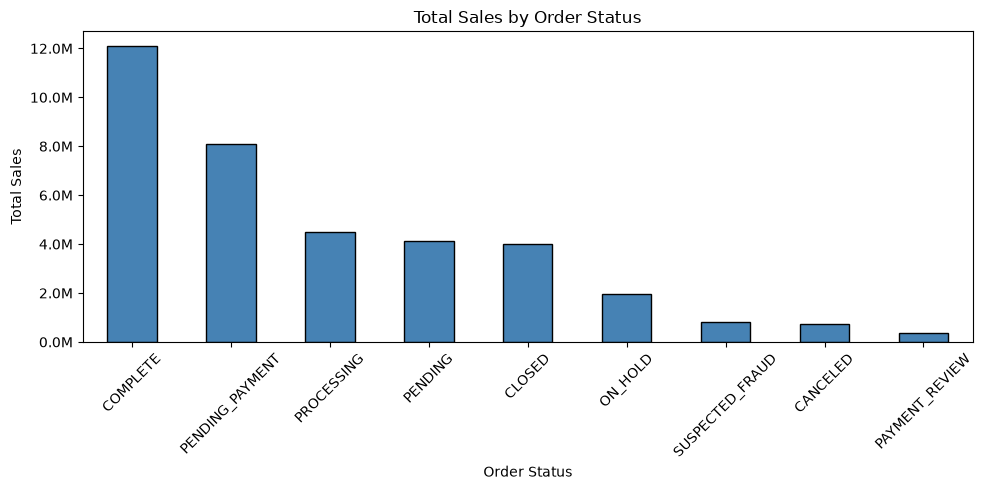

In [161]:
from matplotlib.ticker import FuncFormatter

ax = (
    df.groupby('Order_Status')['Sales']
      .sum()
      .sort_values(ascending=False)
      .plot(
          kind='bar',
          figsize=(10,5),
          color='steelblue',
          edgecolor='black'
      )
)

ax.set_title('Total Sales by Order Status')
ax.set_xlabel('Order Status')
ax.set_ylabel('Total Sales')

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [136]:
order_status_list = df['Order_Status'].unique().tolist()

for status in order_status_list:
    print(f"Order Status: {status}")
    print(df[df['Order_Status'] == status]['Benefit_per_order'].describe())
    print("\n")

Order Status: COMPLETE
count    59487.000000
mean        22.210405
std        103.761052
min      -4274.979980
25%          6.960000
50%         31.500000
75%         64.745000
max        911.799990
Name: Benefit_per_order, dtype: float64


Order Status: PENDING
count    20224.000000
mean        21.529887
std        103.134092
min      -2351.250000
25%          7.087500
50%         31.430000
75%         64.700000
max        720.000000
Name: Benefit_per_order, dtype: float64


Order Status: CLOSED
count    19616.000000
mean        23.347323
std        105.994098
min      -3366.000000
25%          7.920000
50%         31.925000
75%         65.857500
max        697.950010
Name: Benefit_per_order, dtype: float64


Order Status: PENDING_PAYMENT
count    39829.000000
mean        21.186662
std        104.721225
min      -3000.000000
25%          6.840000
50%         31.620000
75%         64.790000
max        720.000000
Name: Benefit_per_order, dtype: float64


Order Status: CANCELED
count    

In [ ]:
# as we can see, the order includes more than one status so, let's filter the data to only include COMPLETE orders.
df_Com_Stat= df[df['Order_Status'] == 'COMPLETE']

### EDA_Function : 
Calculates and displays the main descriptive statistics of a numerical variable for exploratory data analysis (EDA).

In [138]:
# I know we can use df.describe() to get the summary statistics, but I want to create a function that will give me more information about the data.

def EDA (x):
    min_value = x.min()
    max_value = x.max()

    mode_value = x.mode()[0]
    mean_value = x.mean()

    first_quartile = x.quantile(0.25)
    median_value = x.median()
    third_quartile = x.quantile(0.75)

    var = x.var()
    std = x.std()

    skewness = x.skew()
    kurtosis = x.kurtosis()


    print("Minimum: ", min_value)
    print("Maximum: ", max_value)
    print("Mean: ", mean_value)
    print("Mode: ", mode_value)
    print("First Quartile: ", first_quartile)
    print("Median: ", median_value)
    print("Third Quartile: ", third_quartile)
    print("Variance: ", var)
    print("Standard Deviation: ", std)
    print("Skewness: ", skewness)
    print("Kurtosis: ", kurtosis)

In [139]:
EDA(df_Com_Stat['Days_for_shipment_(scheduled)'])

Minimum:  0
Maximum:  4
Mean:  2.926084690772774
Mode:  4
First Quartile:  2.0
Median:  4.0
Third Quartile:  4.0
Variance:  1.8893856434342178
Standard Deviation:  1.3745492510034762
Skewness:  -0.7199653743442119
Kurtosis:  -1.042698531368177


In [140]:
EDA(df_Com_Stat['Sales_per_customer'])

Minimum:  7.49
Maximum:  1939.98999
Mean:  182.5274191184629
Mode:  129.99001
First Quartile:  103.99
Median:  163.96001
Third Quartile:  245.98
Variance:  14772.67140233637
Standard Deviation:  121.54287886312538
Skewness:  3.0822370302476183
Kurtosis:  26.178655217572018


In [141]:
EDA(df_Com_Stat['Sales'])

Minimum:  9.99
Maximum:  1999.98999
Mean:  203.30301456419048
Mode:  129.99001
First Quartile:  119.98
Median:  199.92
Third Quartile:  299.95001
Variance:  18012.21429087546
Standard Deviation:  134.2095909049553
Skewness:  3.091793577111745
Kurtosis:  26.400521165819917


In [142]:
EDA(df_Com_Stat['Benefit_per_order'])

Minimum:  -4274.97998
Maximum:  911.79999
Mean:  22.2104045347723
Mode:  0.0
First Quartile:  6.96
Median:  31.5
Third Quartile:  64.745
Variance:  10766.355814142084
Standard Deviation:  103.76105152773889
Skewness:  -4.844119506496652
Kurtosis:  85.71125616242664


In [143]:
EDA(df_Com_Stat['Order_Profit_Per_Order']) #‼️‼️ we should delete this column because it is the same as Benefit_per_order

Minimum:  -4274.98
Maximum:  911.8
Mean:  22.2104044581169
Mode:  0.0
First Quartile:  6.96
Median:  31.5
Third Quartile:  64.745
Variance:  10766.355838692614
Standard Deviation:  103.76105164604209
Skewness:  -4.844119539733354
Kurtosis:  85.7112570259252


In [144]:
df_Com_Stat.drop('Order_Profit_Per_Order', axis=1, inplace=True)

In [145]:
EDA(df_Com_Stat['Order_Item_Discount'])

Minimum:  0.0
Maximum:  500.0
Mean:  20.77584631768286
Mode:  0.0
First Quartile:  5.4
Median:  14.0
Third Quartile:  30.0
Variance:  487.1975089212961
Standard Deviation:  22.072551028852466
Skewness:  3.09622510240592
Kurtosis:  26.050058625786978


In [146]:
EDA(df_Com_Stat['Order_Item_Profit_Ratio'])

Minimum:  -2.75
Maximum:  0.5
Mean:  0.12013851765932053
Mode:  0.48
First Quartile:  0.08
Median:  0.27
Third Quartile:  0.36
Variance:  0.21944379280191117
Standard Deviation:  0.46844828188596355
Skewness:  -2.886093886411461
Kurtosis:  10.044540705886464


In [147]:
# as we noticed, there are may some columns with same values, regarding they have diff columns names.
# so used my ai assistant to check every column 
# then delete it

duplicate_cols = []

for i in range(len(df_Com_Stat.columns)):
    for j in range(i + 1, len(df_Com_Stat.columns)):
        if df_Com_Stat.iloc[:, i].equals(df_Com_Stat.iloc[:, j]):
            print(f"{df_Com_Stat.columns[i]}  <-->  {df_Com_Stat.columns[j]}")
            duplicate_cols.append(df_Com_Stat.columns[j])  # Keep the first, mark the second

df_Com_Stat = df_Com_Stat.drop(columns=duplicate_cols)

print("Dropped columns:", duplicate_cols)

Sales_per_customer  <-->  Order_Item_Total
Category_Id  <-->  Product_Category_Id
Customer_Email  <-->  Customer_Password
Customer_Id  <-->  Order_Customer_Id
Order_Item_Cardprod_Id  <-->  Product_Card_Id
Dropped columns: ['Order_Item_Total', 'Product_Category_Id', 'Customer_Password', 'Order_Customer_Id', 'Product_Card_Id']


### EDA_Plots(descriptive 0nly):
Here, we will answer some basic business questions.

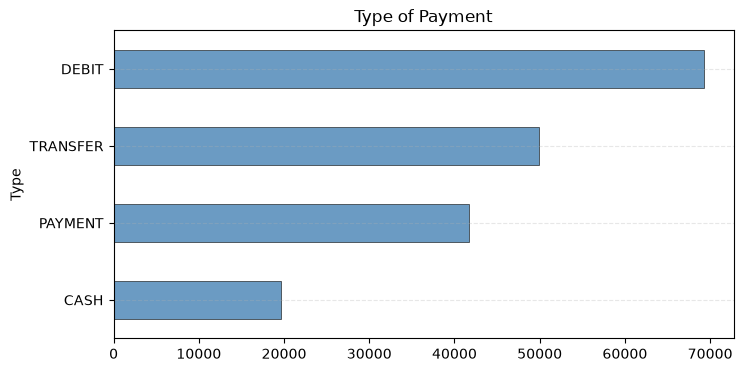

In [157]:
ax= df.groupby(['Type'])['Type'].count().sort_values(ascending=True).plot(kind='barh', title='Type of Payment', figsize=(8, 4), alpha=0.8, color='steelblue', edgecolor='black', linewidth=0.5)
ax.grid(axis='y', linestyle='--', alpha=0.3)

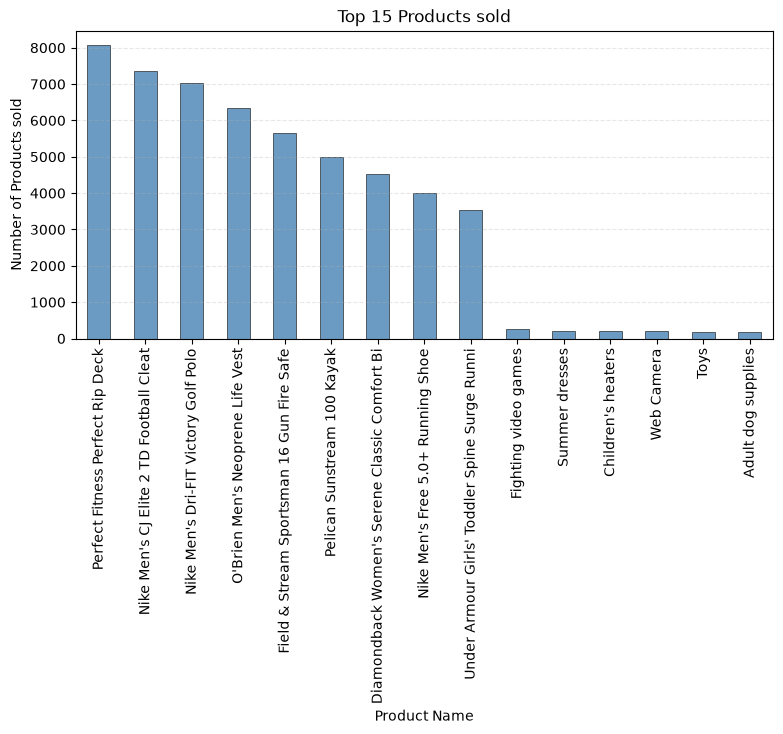

In [159]:
ax= df_Com_Stat.groupby(['Product_Name'])['Product_Name'].count().sort_values(ascending=False).head(15).plot(kind='bar', title='Top 15 Products sold', figsize=(9, 4), xlabel='Product Name', ylabel='Number of Products sold' , alpha=0.8, color='steelblue', edgecolor='black', linewidth=0.5) 
ax.grid(axis='y', linestyle='--', alpha=0.3)

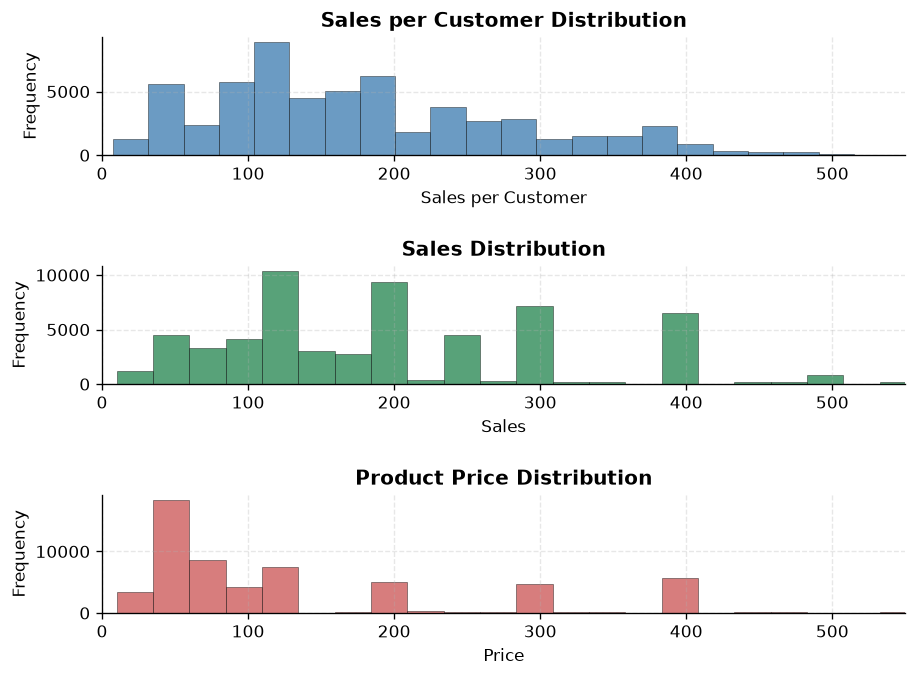

In [150]:
fig, ax = plt.subplots(3, 1, figsize=(8, 6), dpi=120)

ax[0].hist(df_Com_Stat['Sales_per_customer'], bins=80, alpha=0.8,
           color='steelblue', edgecolor='black', linewidth=0.3)
ax[0].set_title('Sales per Customer Distribution', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Sales per Customer')
ax[0].set_ylabel('Frequency')
ax[0].set_xlim(0, 550)
ax[0].grid(alpha=0.3, linestyle='--')
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

ax[2].hist(df_Com_Stat['Product_Price'], bins=80, alpha=0.8,
           color='indianred', edgecolor='black', linewidth=0.3)
ax[2].set_title('Product Price Distribution', fontsize=12, fontweight='bold')
ax[2].set_xlabel('Price')
ax[2].set_ylabel('Frequency')
ax[2].set_xlim(0, 550)
ax[2].grid(alpha=0.3, linestyle='--')
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)

ax[1].hist(df_Com_Stat['Sales'], bins=80, alpha=0.8,
           color='seagreen', edgecolor='black', linewidth=0.3)
ax[1].set_title('Sales Distribution', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Sales')
ax[1].set_ylabel('Frequency')
ax[1].set_xlim(0, 550)
ax[1].grid(alpha=0.3, linestyle='--')
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.tight_layout(pad=2)
plt.show()

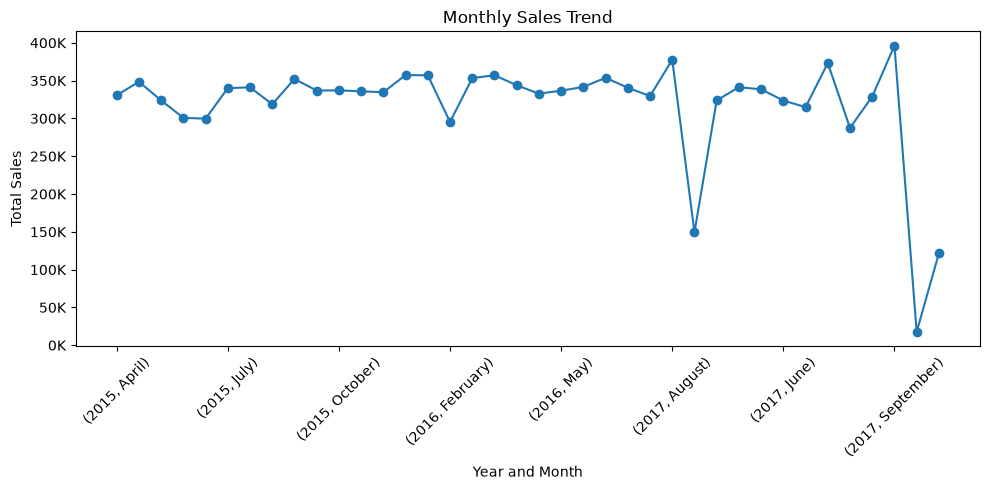

In [160]:
df_Com_Stat['Month_Name'] = df_Com_Stat['shipping_date_(DateOrders)'].dt.month_name()
df_Com_Stat['Year'] = df_Com_Stat['shipping_date_(DateOrders)'].dt.year

from matplotlib.ticker import FuncFormatter


ax = (
    df_Com_Stat.groupby(['Year', 'Month_Name'])['Sales']
      .sum()
      .plot(
          kind='line',
          marker='o',
          figsize=(10, 5),
          title='Monthly Sales Trend',
          xlabel='Year and Month',
          ylabel='Total Sales'
      )
)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()